# 12 — Ajustar las proyecciones teóricas propias

**Entrada única:** la base de casos de 10. Ejecutar todas las celdas; no requiere el kernel de 10 ni 11. Se mantiene el diseño temporal del proyecto: tres bloques futuros respecto al entrenamiento, H1–H5, hiperparámetros fijos, imputación y codificación aprendidas sólo en train.

Se comparan media4, teoría sin ajuste, boosting que ajusta media4, boosting que ajusta teoría y su variante con historia de proyecciones. La fórmula es `máximo(0, teoría + corrección)`. También se mide el sistema que utiliza ajuste de media4 cuando falta una teoría completa. No se usan planos, curvas, plantas ni edades como entradas; sólo producción, clima y proyecciones ya calculadas.

Los bloques ya inspeccionados son desarrollo retrospectivo, no un test prospectivo intacto. No se declara ganador operativo. Las unidades y fechas de disponibilidad conservan las limitaciones del contexto del proyecto.

**Resultado de las salidas ejecutadas actuales:** sobre 1.834 casos comunes, teoría sin ajuste 33,97 % WAPE; boosting teórico 21,68 %; con historia 21,46 % y sin clima 21,31 %. Retirar memoria productiva eleva el WAPE a 25,46 %. La cobertura teórica de los tres bloques es 20,84 %, 12,46 % y 5,45 %. Sobre los 14.108 casos admisibles, sistema con respaldo 21,11 % frente a 21,14 % del ajuste de Media4: mejora global pequeña (0,04 puntos). Estas poblaciones no se mezclan. Las tablas se recalculan al ejecutar; si cambian fuentes, revisar esta síntesis. No es la selección final del notebook 19.

## Diccionario de modelos: cómo leer los nombres de este notebook

Este experimento responde tres preguntas: **¿podemos mejorar la teoría?, ¿qué información ayuda a corregirla? y ¿qué hacemos cuando no hay teoría completa?** Los nombres de las tablas identifican referencias sencillas, modelos aprendidos o combinaciones de rutas; no todos son algoritmos distintos. Esta es una etapa inicial del proyecto: no confundir sus resultados con los del candidato semanal seleccionado posteriormente en el notebook 19.

### Primero: qué significan las palabras de los nombres

| Palabra | Significado en este notebook |
|---|---|
| **Teoría** | Producción teórica de la semana objetivo de la fila. Para estos ajustes se utiliza `teoria_modelo`, que solo conserva proyecciones con cobertura completa. |
| **Media4** | Promedio real de las cuatro semanas anteriores al origen. Es una referencia de cuánto venía produciendo esa serie comercial. |
| **Ajuste o corrección** | Cantidad de tallos que el modelo aprende a sumar o restar a una referencia. Para aprender utiliza diferencias históricas: `real − referencia`. |
| **Memoria productiva** | Producción histórica real disponible antes del origen: rezagos, promedios, variabilidad y cambios. No significa versiones anteriores del plano. |
| **Historia de proyecciones** | Lo que las versiones anteriores del plano proyectaban para la misma semana objetivo: `teoria_previa_1`, `teoria_previa_2` y `revision_teoria`. No significa producción real pasada ni horizontes H1 y H2. |
| **Sin clima / sin memoria** | Experimentos que retiran un bloque de variables para comprobar si ayuda. El algoritmo se vuelve a entrenar; no se limita a ocultar una columna después del entrenamiento. |
| **Ridge** | Regresión lineal regularizada: calcula la corrección combinando las variables con coeficientes y penaliza coeficientes excesivamente grandes. Es una alternativa aprendida más simple que los árboles. |
| **Boosting** | `HistGradientBoostingRegressor`: combina árboles pequeños, incorporados sucesivamente para reducir el error. Puede aprender relaciones que no son rectas y condiciones conjuntas, por ejemplo que una tendencia tenga efectos distintos según el horizonte. |
| **Respaldo** | Ruta usada cuando no hay teoría completa: corregir Media4 usando el historial y las demás variables disponibles. No consiste en sustituir la teoría faltante por cero. |

### Los nombres exactos que aparecen en las tablas

| Nombre en resultados | Qué hace y en qué se basa | Qué pregunta permite responder |
|---|---|---|
| `Ultimo_valor` | Repite `produccion_lag1`, la última producción semanal conocida. No entrena un algoritmo. Desde un mismo origen repite ese valor para H1–H5. | ¿Mejoramos frente a suponer que la producción seguirá igual? |
| `Media4` | Pronostica directamente el promedio de las cuatro semanas anteriores. No aprende una corrección. Desde un mismo origen repite el promedio para H1–H5. | ¿Mejoramos una referencia simple que suaviza cambios semanales? |
| `Teoria_sin_ajuste` | Utiliza directamente `teoria_modelo` para cada semana objetivo. No aprende una corrección. La teoría puede ser diferente en cada horizonte. | ¿Cuánto se equivoca la proyección antes de ajustarla? |
| `Ajuste_media4_sin_planos` | Boosting que aprende `y − media_4`. Usa identidad comercial, horizonte/calendario, memoria productiva y clima. No recibe teoría ni sus revisiones. Pronóstico: Media4 más corrección, limitado a cero como mínimo. | ¿Cuánto podemos predecir apoyándonos en producción real pasada, sin proyecciones teóricas? |
| `Modelo_teorico` | Boosting que aprende `y − teoria_modelo`. Usa identidad comercial, horizonte/calendario, memoria, clima y el bloque de teoría. Pronóstico: teoría más corrección, limitado a cero como mínimo. Es el ajuste teórico **con memoria y con clima**, pero **sin historia de proyecciones**. | ¿Podemos corregir la teoría con la información disponible al pronosticar? |
| `Teorico_sin_memoria` | Mismo tipo de boosting sobre teoría, retirando los rezagos, promedios, variabilidad y cambios de producción histórica, incluida `produccion_52`; también retira `desviacion_reciente_teoria`, porque contiene Media4. Conserva identidad, calendario, clima, teoría y antigüedad del plano. | Frente a `Modelo_teorico`, ¿ayuda añadir el bloque de producción histórica? |
| `Teorico_sin_clima` | Mismo tipo de boosting sobre teoría, retirando las seis variables de clima semanal. Conserva memoria productiva, identidad, calendario y bloque de teoría. | Frente a `Modelo_teorico`, ¿ayuda añadir el clima de esta etapa? |
| `Ridge_ajuste_teoria` | Aprende la corrección sobre teoría con regresión Ridge y las mismas entradas de `Modelo_teorico`; las variables numéricas se estandarizan dentro del entrenamiento. Se suma la corrección a la teoría y se limita a cero como mínimo. | ¿Es suficiente una corrección lineal regularizada o aporta el boosting? |
| `Modelo_teorico_historia` | Mismo boosting y entradas de `Modelo_teorico`, añadiendo las dos teorías previas y su revisión. También conserva memoria de producción real. | ¿Aporta conocer cómo fueron cambiando las proyecciones para la misma semana objetivo? |
| `Sistema_teoria_con_respaldo` | Combina dos modelos: usa `Modelo_teorico` donde hay teoría completa y `Ajuste_media4_sin_planos` donde no la hay. No es un tercer algoritmo ni un promedio de ambas predicciones. | ¿Cómo funciona el sistema sobre toda la población admisible, incluyendo casos sin teoría completa? |

### Qué contiene cada bloque de información

- **Identidad comercial:** `producto`, `color` y `variedad`.
- **Horizonte y calendario:** `horizonte`, `semana_seno` y `semana_coseno`.
- **Memoria productiva:** `produccion_lag1`, `produccion_lag2`, `produccion_lag3`, `media_4`, `media_8`, `desv_4`, `tendencia_4_8`, `cambio_reciente` y `produccion_52`.
- **Clima semanal:** temperatura, humedad y radiación de la semana anterior y sus promedios de cuatro semanas: seis variables. En esta etapa no están las ventanas diarias de corte ni la lluvia añadidas en experimentos posteriores.
- **Bloque de teoría:** `teoria_modelo`, `antiguedad_curva` y `desviacion_reciente_teoria`. La antigüedad se refiere al plano, no a las plantas; el desvío es `media_4 − teoria_modelo`.
- **Historia de proyecciones:** `teoria_previa_1`, `teoria_previa_2` y `revision_teoria`.

Aunque un modelo se llame **sin memoria**, sigue aprendiendo de ejemplos históricos durante su entrenamiento. Lo que se retira son las columnas de producción pasada que recibe como entradas; no se elimina el entrenamiento histórico ni se altera la teoría ya calculada.

### ¿El modelo utiliza todas las columnas de la base?

**No. Cada variante recibe una lista explícita de variables.** El resto de las columnas sirve para identificar registros, unir fuentes, filtrar casos, separar períodos o evaluar resultados. Que una columna esté en el parquet no significa que entre al algoritmo.

El modelo llamado **`Modelo_teorico`** recibe estas **24 columnas**, antes de transformar las categorías en columnas numéricas:

| Bloque | Columnas que recibe | Cantidad |
|---|---|---:|
| Identidad comercial | `producto`, `color`, `variedad` | 3 |
| Horizonte y calendario | `horizonte`, `semana_seno`, `semana_coseno` | 3 |
| Producción histórica | `produccion_lag1`, `produccion_lag2`, `produccion_lag3`, `media_4`, `media_8`, `desv_4`, `tendencia_4_8`, `cambio_reciente`, `produccion_52` | 9 |
| Clima semanal | `temperatura_semana_lag1`, `temperatura_semana_media4`, `humedad_semana_lag1`, `humedad_semana_media4`, `radiacion_semana_lag1`, `radiacion_semana_media4` | 6 |
| Teoría | `teoria_modelo`, `antiguedad_curva`, `desviacion_reciente_teoria` | 3 |

**Cómo cambian las entradas entre variantes:**

| Variante | Entradas al algoritmo | Número de columnas originales |
|---|---|---:|
| `Ajuste_media4_sin_planos` | Identidad, calendario, producción histórica y clima. | 21 |
| `Modelo_teorico` | Los cinco bloques de la tabla anterior. | 24 |
| `Teorico_sin_memoria` | Retira las nueve columnas de producción histórica y `desviacion_reciente_teoria`, porque esta última contiene el promedio de producción pasada. | 14 |
| `Teorico_sin_clima` | Retira las seis columnas meteorológicas. | 18 |
| `Ridge_ajuste_teoria` | Las mismas entradas de `Modelo_teorico`; cambia el algoritmo y se estandarizan las variables numéricas. | 24 |
| `Modelo_teorico_historia` | Las 24 anteriores más `teoria_previa_1`, `teoria_previa_2` y `revision_teoria`. | 27 |
| `Sistema_teoria_con_respaldo` | Usa las entradas de la ruta correspondiente: ajuste teórico si hay cobertura completa o ajuste de Media4 si no la hay. | 24 o 21 |

Las referencias `Ultimo_valor`, `Media4` y `Teoria_sin_ajuste` no entrenan un algoritmo: toman directamente `produccion_lag1`, `media_4` o `teoria_modelo`, respectivamente.

**Columnas que no se entregan como predictores en estos modelos:**

- **`y`:** producción real que se usa para construir la respuesta de entrenamiento (`y − referencia`) y para evaluar después. Nunca se entrega como entrada al pronosticar esa misma semana.
- **`origen` y `semana_objetivo`:** determinan disponibilidad, horizonte y cortes temporales. No se entregan como fechas crudas; el calendario está representado por las variables indicadas arriba.
- **`plano`, `fecha_plano`, `disponible` y las columnas `union_*`:** permiten seleccionar y unir la proyección correcta. No se entregan directamente al algoritmo; de la fecha del plano se deriva `antiguedad_curva`.
- **`curva_completa`, `sin_cobertura`, `cohortes` y `motivo_cobertura`:** documentan cobertura y ayudan a determinar la validez de la teoría. `curva_completa` decide qué ruta del sistema se utiliza.
- **`observaciones_previas` y `admisible_modelo`:** ayudan a seleccionar casos con suficiente historia; no son entradas de estos ajustes.
- **`finca`:** forma parte de la identificación y las uniones, pero no está en la lista de categorías entregadas al algoritmo de este notebook.

**Estos conteos no son el número de columnas finales dentro del algoritmo:** el preprocesamiento convierte producto, color y variedad en indicadores numéricos y puede añadir indicadores de datos faltantes. La imputación y la codificación se aprenden únicamente con el entrenamiento de cada corte.

**Recibir una variable no significa que el modelo la aproveche mucho.** Algunas pueden aportar poca información adicional o solaparse con otras. Comparar variantes que retiran bloques ayuda a estudiar su utilidad predictiva; no demuestra que todas las variables de un bloque ayuden individualmente.

Esta descripción corresponde al **notebook 12**. En etapas posteriores se añaden variables de corte diario y memoria más larga; el candidato seleccionado en el notebook 19 no incluye clima. No deben confundirse las listas de entradas de esas etapas.

### Ejemplo sencillo: qué aprende el ajuste

Supongamos que, en un caso histórico, la teoría era **28.000 tallos** y después se reportaron **24.000**. La corrección que queremos aprender para ese ejemplo es **24.000 − 28.000 = −4.000 tallos**.

Durante el entrenamiento, el algoritmo ve muchos ejemplos con sus variables y sus correcciones reales. Al pronosticar una semana futura, todavía no conoce `y`: calcula una corrección estimada a partir de las entradas disponibles. Si estima −3.000 y la teoría es 28.000, pronostica **25.000 tallos**. Si la suma fuera negativa, se deja en cero.

El ajuste de Media4 funciona igual, pero cambia la referencia: aprende `y − media_4`. Por eso **Media4 sola** y **ajuste de Media4** no son el mismo método.

### Cómo interpretar las comparaciones sin mezclar poblaciones

Los primeros **nueve métodos** se comparan en los mismos casos de evaluación con teoría completa. Los ajustes teóricos se entrenan solo con teoría completa; el ajuste de Media4 conserva todos sus casos admisibles de entrenamiento. Por tanto, comparar teoría frente a Media4 no aísla únicamente el cambio de referencia: también cambia la cobertura de entrenamiento.

Las comparaciones `Modelo_teorico` frente a `Teorico_sin_memoria`, `Teorico_sin_clima` y `Modelo_teorico_historia` mantienen casos de entrenamiento, casos de evaluación y parámetros del boosting; cambia el bloque de entradas. A esto se le llama **ablación** cuando retiramos un bloque. Una reducción de WAPE indica utilidad predictiva en esa evaluación, no causalidad ni que cada variable del bloque aporte por separado.

El **sistema con respaldo** se evalúa además sobre todos los casos admisibles, frente al ajuste de Media4 en esos mismos casos. No debe compararse directamente su WAPE con el de una tabla que solo contiene teoría completa.

En el código también aparecen `Boosting_ajuste_media4`, `Boosting_ajuste_teoria` y `Boosting_historia_teoria`: son los nombres usados al construir los modelos que después se presentan como `Ajuste_media4_sin_planos`, `Modelo_teorico` y `Modelo_teorico_historia`. Las columnas `pred_previo`, `pred_nuevo` y `pred_historia` guardan, respectivamente, esas predicciones.

### Correspondencia con el trabajo escrito

La sección 4.2 del documento formal incorpora este diccionario, las entradas por variante y el funcionamiento de Ridge/boosting. La sección 3.6.1 conecta la evidencia del EDA del notebook 11 y de las tendencias de diario 01 con las comparaciones predictivas. La asociación exploratoria motiva variables, pero no demuestra que cada una mejore el modelo. El anexo recoge el diccionario de las 47 columnas de la base común. La bitácora registra decisiones y siguientes experimentos.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


## Evaluación temporal en casos comunes

En cada corte se entrenan únicamente objetivos cuya semana ya cerró. El ajuste de media4 sin variables de planos conserva todos sus casos de entrenamiento; el ajuste teórico aprende sólo donde la curva está completa. Los nueve métodos se evalúan sobre exactamente los mismos casos con curva completa; además se evalúa el sistema con respaldo sobre todos los casos admisibles. Una menor cobertura no debe confundirse con mejor precisión. No se ajustan hiperparámetros mirando estos bloques.

Se añade una variante con las dos proyecciones anteriores de la misma semana objetivo y la revisión respecto a la anterior. Sólo entran versiones disponibles al origen. Compararla con el ajuste sin historia permite medir su aporte sobre los mismos casos y con los mismos parámetros.

Se incluyen último valor, Ridge y ablaciones sin memoria y sin clima. Los resultados se desagregan por volumen aprendido en train, producto, color, variedad y horizonte. El remuestreo semanal emparejado ofrece una referencia exploratoria de incertidumbre del aporte de historia.

,corte,entrenamiento,entrenamiento_teoria,evaluados,comparables,cobertura
0,2025-07-07,107786,36693,4750,990,0.208421
1,2026-01-05,123537,39836,4767,594,0.124607
2,2026-05-04,133560,41036,4591,250,0.054454


,n,MAE,RMSE,WAPE,sesgo,dentro_8pct_positivos
modelo,,,,,,
Ajuste_media4_sin_planos,1834.0,1756.666923,3170.807892,0.220540,369.967755,0.185387
Media4,1834.0,1942.633860,3697.716947,0.243887,482.624318,0.175573
Modelo_teorico,1834.0,1726.723257,3240.023978,0.216781,608.331183,0.218648
Modelo_teorico_historia,1834.0,1709.428715,3215.320439,0.214610,605.694089,0.223555
Ridge_ajuste_teoria,1834.0,1782.900253,3390.726552,0.223834,850.284302,0.200654
Teoria_sin_ajuste,1834.0,2706.053390,5568.254928,0.339730,-1207.757572,0.184297
Teorico_sin_clima,1834.0,1697.082066,3201.633456,0.213060,633.898759,0.218648
Teorico_sin_memoria,1834.0,2027.958648,3790.338446,0.254599,722.573315,0.181025
Ultimo_valor,1834.0,1764.368048,3425.796227,0.221507,372.663577,0.205562


n          MAE         RMSE      WAPE  \
modelo                   horizonte                                              
Ajuste_media4_sin_planos 1.0        382.0  1222.970000  2081.731898  0.166493   
                         2.0        370.0  1545.137575  2696.500611  0.201919   
                         3.0        361.0  1717.647885  3099.144455  0.211169   
                         4.0        359.0  2080.923385  3618.915616  0.248980   
                         5.0        362.0  2253.395890  4045.449594  0.268843   
Media4                   1.0        382.0  1282.014398  2381.462159  0.174531   
                         2.0        370.0  1698.316892  3165.341493  0.221937   
                         3.0        361.0  2009.335180  3695.490122  0.247029   
                         4.0        359.0  2347.259749  4514.613692  0.280846   
                         5.0        362.0  2421.678177  4383.469174  0.288920   
Modelo_teorico           1.0        382.0  1417.255988  2576.807423  0.192943   
                         2.0        370.0  1577.853386  2927.759005  0.206195   
                         3.0        361.0  1727.934354  3223.694706  0.212433   
                         4.0        359.0  1931.341152  3632.023136  0.231082   
                         5.0        362.0  2001.318062  3737.780537  0.238768   
Modelo_teorico_historia  1.0        382.0  1411.458835  2525.912117  0.192154   
                         2.0        370.0  1584.543790  2894.143042  0.207069   
                         3.0        361.0  1680.208329  3119.906352  0.206566   
                         4.0        359.0  1899.467666  3605.137061  0.227269   
                         5.0        362.0  1992.181456  3806.140778  0.237678   
Ridge_ajuste_teoria      1.0        382.0  1517.016155  2634.511862  0.206524   
                         2.0        370.0  1591.572666  2852.650951  0.207988   
                         3.0        361.0  1737.851694  3183.745770  0.213653   
                         4.0        359.0  2001.656208  3937.643025  0.239495   
                         5.0        362.0  2087.010959  4137.755880  0.248992   
Teoria_sin_ajuste        1.0        382.0  3004.080659  6157.146997  0.408971   
                         2.0        370.0  2798.455085  5730.520199  0.365704   
                         3.0        361.0  2579.293492  5219.776291  0.317100   
                         4.0        359.0  2589.739351  5384.824875  0.309859   
                         5.0        362.0  2538.876648  5252.289643  0.302902   
Teorico_sin_clima        1.0        382.0  1384.920064  2478.494588  0.188541   
                         2.0        370.0  1555.359456  2868.558862  0.203255   
                         3.0        361.0  1692.299477  3152.277102  0.208052   
                         4.0        359.0  1889.330269  3610.887754  0.226056   
                         5.0        362.0  1985.459581  3768.184245  0.236876   
Teorico_sin_memoria      1.0        382.0  1974.736192  3579.057262  0.268838   
                         2.0        370.0  1881.099329  3537.964838  0.245823   
                         3.0        361.0  2053.494452  3745.778586  0.252458   
                         4.0        359.0  2139.415523  4056.915792  0.255978   
                         5.0        362.0  2098.227939  4019.995318  0.250330   
Ultimo_valor             1.0        382.0  1074.020942  1823.127960  0.146216   
                         2.0        370.0  1431.289189  2681.825212  0.187042   
                         3.0        361.0  1763.371191  3337.067830  0.216790   
                         4.0        359.0  2247.568245  4257.077770  0.268918   
                         5.0        362.0  2355.093923  4418.386463  0.280976   

                                          sesgo  dentro_8pct_positivos  
modelo                   horizonte                                      
Ajuste_media4_sin_planos 1.0         207.891507               0.219895  
             

n          MAE         RMSE  \
modelo                   corte                                         
Ajuste_media4_sin_planos 2025-07-07  990.0  1758.608228  3329.061463   
                         2026-01-05  594.0  1917.310666  3331.486290   
                         2026-05-04  250.0  1367.289821  1870.364831   
Media4                   2025-07-07  990.0  1963.113384  3921.887783   
                         2026-01-05  594.0  2078.037879  3854.096678   
                         2026-05-04  250.0  1539.815000  2025.616731   
Modelo_teorico           2025-07-07  990.0  1692.362068  3547.071785   
                         2026-01-05  594.0  1667.596239  2861.219004   
                         2026-05-04  250.0  2003.279366  2781.479628   
Modelo_teorico_historia  2025-07-07  990.0  1660.906096  3461.171767   
                         2026-01-05  594.0  1688.107381  2966.086826   
                         2026-05-04  250.0  1952.237771  2738.383569   
Ridge_ajuste_teoria      2025-07-07  990.0  1735.982886  3570.053506   
                         2026-01-05  594.0  1908.522541  3504.056955   
                         2026-05-04  250.0  1670.214470  2167.338357   
Teoria_sin_ajuste        2025-07-07  990.0  2904.754631  6301.353524   
                         2026-01-05  594.0  2667.176675  5109.874413   
                         2026-05-04  250.0  2011.567551  2859.516294   
Teorico_sin_clima        2025-07-07  990.0  1702.394890  3518.983847   
                         2026-01-05  594.0  1594.228429  2812.652793   
                         2026-05-04  250.0  1920.423527  2713.506631   
Teorico_sin_memoria      2025-07-07  990.0  1967.142088  4182.903091   
                         2026-01-05  594.0  1902.978154  3229.263064   
                         2026-05-04  250.0  2565.745881  3365.969687   
Ultimo_valor             2025-07-07  990.0  1757.192929  3531.426376   
                         2026-01-05  594.0  1902.890572  3710.639623   
                         2026-05-04  250.0  1463.652000  1999.012791   

                                         WAPE        sesgo  \
modelo                   corte                               
Ajuste_media4_sin_planos 2025-07-07  0.230797   320.775462   
                         2026-01-05  0.229800   647.458095   
                         2026-05-04  0.162090   -94.547808   
Media4                   2025-07-07  0.257636   553.098232   
                         2026-01-05  0.249064  1020.269360   
                         2026-05-04  0.182542 -1073.897000   
Modelo_teorico           2025-07-07  0.222103   447.768226   
                         2026-01-05  0.199871   451.413296   
                         2026-05-04  0.237485  1616.997390   
Modelo_teorico_historia  2025-07-07  0.217974   414.749201   
                         2026-01-05  0.202329   511.227790   
                         2026-05-04  0.231434  1586.287770   
Ridge_ajuste_teoria      2025-07-07  0.227827   805.340268   
                         2026-01-05  0.228747   851.716803   
                         2026-05-04  0.198001  1024.859053   
Teoria_sin_ajuste        2025-07-07  0.381215 -1269.134608   
                         2026-01-05  0.319676 -1736.421158   
                         2026-05-04  0.238467   291.400170   
Teorico_sin_clima        2025-07-07  0.223419   609.957217   
                         2026-01-05  0.191077   402.980880   
                         2026-05-04  0.227662  1277.368144   
Teorico_sin_memoria      2025-07-07  0.258164   680.910295   
                         2026-01-05  0.228082   277.640370   
                         2026-05-04  0.304164  1944.719556   
Ultimo_valor             2025-07-07  0.230611   288.225253   
                         2026-01-05  0.228072   969.153199   
                         2026-05-04  0.173513  -710.220000   

                                     dentro_8pct_positivos  
modelo                   corte                              
Ajuste_media4_sin_planos 2025-0

n          MAE         RMSE  \
modelo                   producto                                           
Ajuste_media4_sin_planos BARBATUS           3.0   168.404435   201.022520   
                         CARNATION       1096.0  1058.734041  1620.233659   
                         GREEN BALL        47.0  1833.828109  2203.331194   
                         MINICARNATION    269.0  3352.409323  4759.742735   
                         RAFFINE          156.0  5429.187670  7561.325821   
...                                         ...          ...          ...   
Ultimo_valor             RAFFINE          156.0  5646.884615  7929.854569   
                         SOLOMIO           55.0   840.436364  1149.127638   
                         TRACHELIUM        80.0  1222.775000  1532.469315   
                         VERONICA          89.0   726.528090   871.159869   
                         VERONICA SPRAY    39.0   588.461538   703.475438   

                                             WAPE        sesgo  \
modelo                   producto                                
Ajuste_media4_sin_planos BARBATUS        0.842022   168.404435   
                         CARNATION       0.241901    31.257196   
                         GREEN BALL      0.381589 -1310.106666   
                         MINICARNATION   0.167222   624.757485   
                         RAFFINE         0.254723  3749.667799   
...                                           ...          ...   
Ultimo_valor             RAFFINE         0.264937  2112.371795   
                         SOLOMIO         0.181171  -177.090909   
                         TRACHELIUM      0.310860   753.525000   
                         VERONICA        0.322009  -362.483146   
                         VERONICA SPRAY  0.237750   284.102564   

                                         dentro_8pct_positivos  
modelo                   producto                               
Ajuste_media4_sin_planos BARBATUS                     0.000000  
                         CARNATION                    0.172445  
                         GREEN BALL                   0.127660  
                         MINICARNATION                0.278810  
                         RAFFINE                      0.166667  
...                                                        ...  
Ultimo_valor             RAFFINE                      0.141026  
                         SOLOMIO                      0.254545  
                         TRACHELIUM                   0.175000  
                         VERONICA                     0.123596  
                         VERONICA SPRAY               0.128205  

[81 rows x 6 columns]

,n,MAE,RMSE,WAPE,sesgo,dentro_8pct_positivos
modelo,,,,,,
Ajuste_media4_sin_planos,14108.0,2246.786932,4103.533505,0.211444,572.506165,0.205982
Sistema_teoria_con_respaldo,14108.0,2242.894340,4110.556071,0.211077,603.492734,0.210306


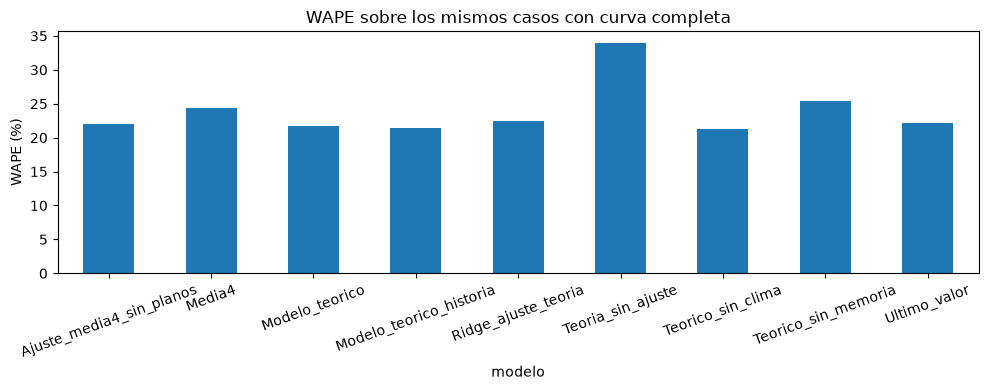

n          MAE         RMSE  \
modelo                   segmento_volumen                                     
Ajuste_media4_sin_planos alto              1662.0  1874.286274  3319.692064   
                         bajo               169.0   629.984319   853.925285   
Media4                   alto              1662.0  2084.976083  3876.787671   
                         bajo               169.0   576.587278   759.469842   
Modelo_teorico           alto              1662.0  1847.380463  3393.590085   
                         bajo               169.0   569.633869   815.976855   
Modelo_teorico_historia  alto              1662.0  1829.149380  3367.833585   
                         bajo               169.0   561.242567   804.917843   
Ridge_ajuste_teoria      alto              1662.0  1906.767690  3553.069840   
                         bajo               169.0   578.645034   772.878261   
Teoria_sin_ajuste        alto              1662.0  2931.120120  5843.695097   
                         bajo               169.0   538.657447   802.001016   
Teorico_sin_clima        alto              1662.0  1814.890174  3353.456984   
                         bajo               169.0   567.485445   803.151657   
Teorico_sin_memoria      alto              1662.0  2174.874309  3971.533505   
                         bajo               169.0   617.982604   889.099730   
Ultimo_valor             alto              1662.0  1889.899519  3590.007012   
                         bajo               169.0   560.071006   783.904150   

                                               WAPE        sesgo  \
modelo                   segmento_volumen                          
Ajuste_media4_sin_planos alto              0.217968   422.203766   
                         bajo              0.336093  -138.330150   
Media4                   alto              0.242470   538.328670   
                         bajo              0.307606   -55.930473   
Modelo_teorico           alto              0.214839   639.730357   
                         bajo              0.303897   309.180689   
Modelo_teorico_historia  alto              0.212719   637.676126   
                         bajo              0.299420   300.764723   
Ridge_ajuste_teoria      alto              0.221745   925.186158   
                         bajo              0.308704   146.521705   
Teoria_sin_ajuste        alto              0.340871 -1332.511618   
                         bajo              0.287371    -0.271654   
Teorico_sin_clima        alto              0.211061   665.022490   
                         bajo              0.302751   337.910919   
Teorico_sin_memoria      alto              0.252925   762.865533   
                         bajo              0.329691   337.993759   
Ultimo_valor             alto              0.219784   410.064380   
                         bajo              0.298795    12.047337   

                                           dentro_8pct_positivos  
modelo                   segmento_volumen                         
Ajuste_media4_sin_planos alto                           0.190132  
                         bajo                           0.142012  
Media4                   alto                           0.180505  
                         bajo                           0.130178  
Modelo_teorico           alto                           0.226233  
                         bajo                           0.147929  
Modelo_teorico_historia  alto                           0.230445  
                         bajo                           0.159763  
Ridge_ajuste_teoria      alto                           0.208183  
                         bajo                           0.130178  
Teoria_sin_ajuste        alto                           0.178700  
                         bajo                           0.242604  
Teorico_sin_clima        alto                           0.225632  
                         bajo                           0.153846  
Teorico_sin_memoria      alto     

,series,mediana_WAPE
modelo,,
Ajuste_media4_sin_planos,64,0.245914
Media4,64,0.276371
Modelo_teorico,64,0.196486
Modelo_teorico_historia,64,0.199712
Ridge_ajuste_teoria,64,0.233284
Teoria_sin_ajuste,64,0.278032
Teorico_sin_clima,64,0.210775
Teorico_sin_memoria,64,0.257313
Ultimo_valor,64,0.260802


n           MAE  \
modelo                   producto       color                                   
Ajuste_media4_sin_planos BARBATUS       PURPLE              3.0    168.404435   
                         CARNATION      BICOLOR BURGUNDY   10.0    272.692270   
                                        BICOLOR PINK       30.0   1244.455213   
                                        BICOLOR PURPLE     88.0    589.995908   
                                        BICOLOR RED        20.0   1738.168292   
                                        BICOLOR YELLOW     92.0   1840.510905   
                                        CREAM              28.0   1367.425238   
                                        DARK PINK          20.0    426.685653   
                                        GOLD               31.0   1502.670671   
                                        GREEN             160.0    515.345709   
                                        LAVENDER           19.0   1366.638137   
                                        ORANGE            117.0   1030.624250   
                                        PEACH              13.0    650.381330   
                                        PURPLE            122.0    793.979740   
                                        RED                65.0    847.853415   
                                        VINTAGE           104.0    714.144913   
                                        WHITE             109.0   1158.339489   
                                        YELLOW             68.0   2660.764735   
                         GREEN BALL     GREEN              47.0   1833.828109   
                         MINICARNATION  BICOLOR PURPLE     10.0   2224.206742   
                                        BICOLOR RED        90.0   2029.281716   
                                        BURGUNDY           26.0   5006.736386   
                                        CREAM              36.0   4017.462201   
                                        GREEN              50.0   2842.389854   
                                        LIGHT PINK          6.0   3444.334436   
                                        ORANGE              1.0   2059.989185   
                                        RED                 3.0  10490.932927   
                                        WHITE              31.0   2554.507864   
                                        YELLOW             16.0   9163.054359   
                         RAFFINE        BICOLOR BURGUNDY   74.0   6357.911007   
                                        BICOLOR PURPLE     26.0   1671.868226   
                                        LAVENDER           22.0    583.276311   
                                        LIGHT PINK         34.0   9416.682623   
                         SOLOMIO        BICOLOR PURPLE     35.0   1100.317851   
                                        LAVENDER           10.0    525.226624   
                                        RED                10.0    565.303401   
                         TRACHELIUM     PURPLE             80.0   1013.851006   
                         VERONICA       PURPLE             45.0    672.829535   
                                        WHITE              44.0    893.770107   
                         VERONICA SPRAY PINK                9.0    827.537097   

                                                                  RMSE  \
modelo                   producto       color                            
Ajuste_media4_sin_planos BARBATUS       PURPLE              201.022520   
                         CARNATION      BICOLOR BURGUNDY    298.400367   
                                        BICOLOR PINK       1579.510873   
                                        BICOLOR PURPLE      748.398737   
                                        BICOLOR RED        2131.692975   
                                        BICOLOR YELLOW     2424.214465   
                                        CREAM              1585.910

,bloque,referencia,completo,reduccion_puntos_WAPE
0,producción reciente,Teorico_sin_memoria,Modelo_teorico,3.781849
1,clima,Teorico_sin_clima,Modelo_teorico,-0.372129
2,proyecciones anteriores,Modelo_teorico,Modelo_teorico_historia,0.217124


Aporte historia, intervalo exploratorio 95% por remuestreo semanal: [-0.01179752  0.44829465] puntos WAPE.
El remuestreo no elimina toda dependencia temporal ni convierte estos bloques en validación prospectiva.


In [3]:
llave_caso=KEY+['origen','semana_objetivo','horizonte']
resultados,operativos,coberturas=[],[],[]
for corte in CORTES:
    train=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    test=datos.loc[datos.origen.ge(corte)&datos.origen.lt(corte+pd.Timedelta(weeks=SEMANAS_EVALUACION))].copy()
    tc=train.loc[train.curva_completa]
    assert len(tc)>0 and len(test)>0
    previo=crear_modelo('Boosting_ajuste_media4',X_columnas)
    nuevo=crear_modelo('Boosting_ajuste_teoria',X_teoria)
    historia=crear_modelo('Boosting_historia_teoria',X_historia)
    with threadpool_limits(limits=2):
        previo.fit(train[X_columnas],train.y-train.media_4)
        nuevo.fit(tc[X_teoria],tc.y-tc.teoria_modelo)
        historia.fit(tc[X_historia],tc.y-tc.teoria_modelo)
        test['pred_previo']=np.maximum(0,test.media_4+previo.predict(test[X_columnas]))
        comunes=test.loc[test.curva_completa].copy()
        assert len(comunes)>0
        comunes['pred_nuevo']=np.maximum(0,comunes.teoria_modelo+nuevo.predict(comunes[X_teoria]))
        comunes['pred_historia']=np.maximum(0,comunes.teoria_modelo+historia.predict(comunes[X_historia]))
    # Ablaciones: mismos casos, train y parámetros; sólo cambia el bloque de variables.
    variantes={
        'Teorico_sin_clima':[c for c in X_teoria if c not in climaticas],
        'Teorico_sin_memoria':[c for c in X_teoria if c not in memoria+['desviacion_reciente_teoria']],
        'Ridge_ajuste_teoria':X_teoria,
    }
    for etiqueta,columnas in variantes.items():
        candidato=crear_modelo(etiqueta,columnas)
        with threadpool_limits(limits=2):
            candidato.fit(tc[columnas],tc.y-tc.teoria_modelo)
            comunes[etiqueta]=np.maximum(0,comunes.teoria_modelo+candidato.predict(comunes[columnas]))
    for nombre,valores in [('Ultimo_valor',comunes.produccion_lag1),('Teorico_sin_clima',comunes.Teorico_sin_clima),('Teorico_sin_memoria',comunes.Teorico_sin_memoria),('Ridge_ajuste_teoria',comunes.Ridge_ajuste_teoria),('Media4',comunes.media_4),('Teoria_sin_ajuste',comunes.teoria_modelo),('Ajuste_media4_sin_planos',comunes.pred_previo),('Modelo_teorico',comunes.pred_nuevo),('Modelo_teorico_historia',comunes.pred_historia)]:
        r=comunes[llave_caso+['y']].copy();r['modelo']=nombre;r['prediccion']=np.asarray(valores);r['corte']=corte;resultados.append(r)
    test['prediccion']=test.pred_previo
    test.loc[comunes.index,'prediccion']=comunes.pred_nuevo
    test['ruta']=np.where(test.curva_completa,'ajuste_teoria','respaldo_media4')
    test['corte']=corte
    operativos.append(test[llave_caso+['y','prediccion','pred_previo','ruta','corte']])
    coberturas.append(dict(corte=corte,entrenamiento=len(train),entrenamiento_teoria=len(tc),evaluados=len(test),comparables=len(comunes),cobertura=len(comunes)/len(test)))
predicciones_teoria=pd.concat(resultados,ignore_index=True)
predicciones_sistema=pd.concat(operativos,ignore_index=True)
assert not predicciones_teoria.duplicated(['modelo']+llave_caso).any()
assert predicciones_teoria.groupby(llave_caso).modelo.nunique().eq(9).all()
def evaluar(g):
    e=g.y-g.prediccion
    positivos=g.y.gt(0)
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.y.sum() if g.y.sum()>0 else np.nan,'sesgo':e.mean(),'dentro_8pct_positivos':(e[positivos].abs()<=.08*g.loc[positivos,'y']).mean()})
metricas_comunes=predicciones_teoria.groupby('modelo').apply(evaluar)
display(pd.DataFrame(coberturas)); display(metricas_comunes)
display(predicciones_teoria.groupby(['modelo','horizonte']).apply(evaluar))
display(predicciones_teoria.groupby(['modelo','corte']).apply(evaluar))
display(predicciones_teoria.groupby(['modelo','producto']).apply(evaluar))
comparacion_sistema=pd.concat([predicciones_sistema.assign(modelo='Sistema_teoria_con_respaldo'),predicciones_sistema.assign(modelo='Ajuste_media4_sin_planos',prediccion=predicciones_sistema.pred_previo)])
metricas_sistema=comparacion_sistema.groupby('modelo').apply(evaluar)
display(metricas_sistema)
metricas_comunes.WAPE.mul(100).plot.bar(title='WAPE sobre los mismos casos con curva completa',ylabel='WAPE (%)',rot=20,figsize=(10,4));plt.tight_layout();plt.show()

# El umbral de bajo volumen se aprende en cada train, nunca en el test.
segmentos=[]
for corte in CORTES:
    historico=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)].drop_duplicates(KEY+['semana_objetivo'])
    volumen=historico.groupby(KEY,as_index=False).y.mean().rename(columns={'y':'volumen_train'})
    umbral=volumen.volumen_train.median()
    volumen['segmento_volumen']=np.where(volumen.volumen_train.le(umbral),'bajo','alto')
    d=predicciones_teoria.loc[predicciones_teoria.corte.eq(corte)].merge(volumen,on=KEY,how='left',validate='many_to_one')
    segmentos.append(d)
por_segmento=pd.concat(segmentos,ignore_index=True).groupby(['modelo','segmento_volumen']).apply(evaluar)
por_variedad=predicciones_teoria.groupby(['modelo']+KEY).apply(evaluar)
display(por_segmento)
display(por_variedad.groupby('modelo').agg(series=('n','size'),mediana_WAPE=('WAPE','median')))
display(predicciones_teoria.groupby(['modelo','producto','color']).apply(evaluar).head(40))
aportes=pd.DataFrame([
    {'bloque':'producción reciente','referencia':'Teorico_sin_memoria','completo':'Modelo_teorico'},
    {'bloque':'clima','referencia':'Teorico_sin_clima','completo':'Modelo_teorico'},
    {'bloque':'proyecciones anteriores','referencia':'Modelo_teorico','completo':'Modelo_teorico_historia'}])
aportes['reduccion_puntos_WAPE']=[100*(metricas_comunes.loc[r.referencia,'WAPE']-metricas_comunes.loc[r.completo,'WAPE']) for r in aportes.itertuples()]
display(aportes)
# Incertidumbre emparejada por semana objetivo: conserva juntos casos del mismo target.
comparables=predicciones_teoria.loc[predicciones_teoria.modelo.isin(['Modelo_teorico','Modelo_teorico_historia'])].copy()
comparables['error_abs']=(comparables.y-comparables.prediccion).abs()
bloques=comparables.groupby(['semana_objetivo','modelo']).agg(error=('error_abs','sum'),real=('y','sum'))
errores=bloques.error.unstack();reales=bloques.real.unstack().iloc[:,0]
rng=np.random.default_rng(42);deltas=[]
for _ in range(500):
    indices=rng.integers(0,len(errores),len(errores))
    d=errores.iloc[indices].sum()/reales.iloc[indices].sum()
    deltas.append(100*(d['Modelo_teorico']-d['Modelo_teorico_historia']))
print('Aporte historia, intervalo exploratorio 95% por remuestreo semanal:',np.quantile(deltas,[.025,.975]),'puntos WAPE.')
print('El remuestreo no elimina toda dependencia temporal ni convierte estos bloques en validación prospectiva.')


### Interpretación de la comparación

Las ablaciones miden utilidad predictiva condicional, no causalidad. El resultado de historia debe leerse con su cobertura y el intervalo exploratorio. El sistema de salida usa el ajuste teórico sin historia como candidato fijado antes de evaluar; la variante con historia sigue siendo un experimento, aunque su métrica resulte mejor. No se elige automáticamente el ganador del mismo test.

La sensibilidad a la disponibilidad real permanece pendiente: las fechas de planos y las ediciones anuales no son registros de publicación. Los controles del código impiden usar fechas posteriores bajo el supuesto adoptado, pero no certifican ese supuesto.

## Simulación desde el último origen local y exportación

Se reentrenan ambos modelos con semanas cerradas al último origen de la base. Se emiten cinco horizontes para las series que cumplen los requisitos de memoria de 09. La columna `ruta` indica si se utilizó teoría o respaldo; una curva parcial nunca se presenta como completa. Es una simulación con la fecha local de los archivos, no una emisión histórica ni una actualización a la fecha de hoy. El modelo teórico es un candidato fijado antes de esta comparación, no un ganador garantizado.

In [4]:
origen_local=integrados.origen.max()
train=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(origen_local)]
tc=train.loc[train.curva_completa]
futuro=integrados.loc[integrados.origen.eq(origen_local)&integrados.media_4.notna()&integrados.observaciones_previas.ge(26)].copy()
previo=crear_modelo('Boosting_ajuste_media4',X_columnas)
nuevo=crear_modelo('Boosting_ajuste_teoria',X_teoria)
with threadpool_limits(limits=2):
    previo.fit(train[X_columnas],train.y-train.media_4)
    nuevo.fit(tc[X_teoria],tc.y-tc.teoria_modelo)
    futuro['prediccion']=np.maximum(0,futuro.media_4+previo.predict(futuro[X_columnas]))
    tiene=futuro.curva_completa
    if tiene.any(): futuro.loc[tiene,'prediccion']=np.maximum(0,futuro.loc[tiene,'teoria_modelo']+nuevo.predict(futuro.loc[tiene,X_teoria]))
futuro['ruta']=np.where(futuro.curva_completa,'ajuste_teoria','respaldo_media4')
salida_operativa=futuro[llave_caso+['plano','disponible','teoria','sin_cobertura','teoria_modelo','media_4','prediccion','ruta']]
assert salida_operativa.prediccion.notna().all() and salida_operativa.prediccion.ge(0).all()
assert not salida_operativa.duplicated(llave_caso).any()
display(salida_operativa);display(salida_operativa.groupby('ruta').size().rename('casos'))
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
DESTINO.mkdir(exist_ok=True)
predicciones_teoria.to_parquet(DESTINO/'evaluacion_casos_comunes.parquet',index=False)
predicciones_sistema.to_parquet(DESTINO/'evaluacion_sistema.parquet',index=False)
salida_operativa.to_parquet(DESTINO/'simulacion_ultimo_origen.parquet',index=False)
with pd.ExcelWriter(DESTINO/'resultados_modelo_teorico.xlsx') as writer:
    metricas_comunes.to_excel(writer,sheet_name='Metricas_casos_comunes')
    metricas_sistema.to_excel(writer,sheet_name='Metricas_sistema')
    aportes.to_excel(writer,sheet_name='Aportes',index=False)
    por_segmento.to_excel(writer,sheet_name='Volumen')
    por_variedad.to_excel(writer,sheet_name='Variedad')
    pd.DataFrame(coberturas).to_excel(writer,sheet_name='Cobertura',index=False)
    salida_operativa.to_excel(writer,sheet_name='Simulacion',index=False)
diferencia=100*(metricas_comunes.loc['Ajuste_media4_sin_planos','WAPE']-metricas_comunes.loc['Modelo_teorico','WAPE'])
print(f'Diferencia a favor del modelo teórico sobre casos comunes: {diferencia:.2f} puntos de WAPE (negativa significa que empeora).')
print('Origen de la simulación:',origen_local,'; resultados:',DESTINO)
print('Pendientes: disponibilidad histórica de ediciones, publicación real de planos y equivalencia entre flores teóricas y tallos reportados. No se ha certificado producción exportable.')

print("Aporte de proyecciones previas (puntos de WAPE):",100*(metricas_comunes.loc["Modelo_teorico","WAPE"]-metricas_comunes.loc["Modelo_teorico_historia","WAPE"]))

,finca,producto,color,variedad,origen,semana_objetivo,horizonte,plano,disponible,teoria,sin_cobertura,teoria_modelo,media_4,prediccion,ruta
1015,GAITANA,AMAZON,PURPLE,NEON PURPLE,2026-09-07,2026-09-07,1.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,1657.059524,5.0,NaN,2182.5,3003.517841,respaldo_media4
4421,GAITANA,BARBATUS,HOT PINK,WONDER,2026-09-07,2026-09-07,1.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,2528.895600,7.0,NaN,1837.5,2466.426948,respaldo_media4
4885,GAITANA,BARBATUS,LAVENDER,MELIAN,2026-09-07,2026-09-07,1.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,2073.444196,4.0,NaN,1822.5,2433.898698,respaldo_media4
5274,GAITANA,BARBATUS,LIGHT PINK,NOBLE,2026-09-07,2026-09-07,1.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,1830.436828,5.0,NaN,1365.0,2036.757082,respaldo_media4
6372,GAITANA,BARBATUS,RED,AMRAS,2026-09-07,2026-09-07,1.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,1761.999306,5.0,NaN,1372.5,2001.581619,respaldo_media4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620234,GAITANA,VERONICA,PURPLE,SKYLER BLUE,2026-09-07,2026-10-05,5.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,2108.341608,0.0,2108.341608,1297.5,1690.884218,ajuste_teoria
620693,GAITANA,VERONICA,WHITE,SKYLER WHITE,2026-09-07,2026-10-05,5.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,2504.002064,1.0,NaN,2250.0,2486.756699,respaldo_media4
620945,GAITANA,VERONICA SPRAY,PINK,SKYLER SPLASH PINK,2026-09-07,2026-10-05,5.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,3646.059426,6.0,NaN,1605.0,1937.720897,respaldo_media4
621068,GAITANA,VERONICA SPRAY,PURPLE,SKYLER SPLASH BLUE,2026-09-07,2026-10-05,5.0,2026/Plano de Siembras Sem 33.xlsx,2026-08-20,3826.394835,4.0,NaN,1582.5,2066.249634,respaldo_media4


ruta
ajuste_teoria       59
respaldo_media4    531
Name: casos, dtype: int64

Diferencia a favor del modelo teórico sobre casos comunes: 0.38 puntos de WAPE (negativa significa que empeora).
Origen de la simulación: 2026-09-07 00:00:00 ; resultados: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos_analiticos_proyecto\modelo_con_proyecciones_teoricas
Pendientes: disponibilidad histórica de ediciones, publicación real de planos y equivalencia entre flores teóricas y tallos reportados. No se ha certificado producción exportable.
Aporte de proyecciones previas (puntos de WAPE): 0.21712369451784008
